### IMPORTATION DES BIBLIOTHEQUES ET PARAMETRES GLOBAUX

In [1]:
# ---  Préambule : imports ---
%matplotlib inline

import os, sys, importlib
from pathlib import Path
import ipynbname
import geopandas as gpd
import pandas as pd

# ---  Définition des chemins de base ---
base_path = Path(ipynbname.path()).parent.parent.parent  # racine du projet
path_data = base_path / 'Data'

# ---  Ajouter dossier scripts au Python path ---
scripts_path = base_path / 'Code' / 'Formatage'/'scripts'
sys.path.append(str(scripts_path.resolve()))

print("📌 **CONFIGURATION DES CHEMINS**")
print(f"📍 base_path    : {base_path}")
print(f"📂 path_data     : {path_data}")
print(f"📂 scripts_path  : {scripts_path}")


📌 **CONFIGURATION DES CHEMINS**
📍 base_path    : D:\MANTIS
📂 path_data     : D:\MANTIS\Data
📂 scripts_path  : D:\MANTIS\Code\Formatage\scripts


### CREATION DE LA GRILLE

In [ ]:
# Paramètres pour l'importation des données géographiques et la création de la grille
geo_file = path_data/'SIG'/'SIG_global'/'geoBoundariesCGAZ_ADM0.geojson'
#geo_file = path_data/'SIG_global'/'communes-20220101-shp'/'Martigues+.shp'

zone="India"
name_attribute="shapeName"
code_attribute='shapeGroup'
cell_sizes_km=[20]
tolerance=0

# Créer le dossier (et les parents si nécessaire) s'il n'existe pas
output = path_data /"SIG"/ "SIG_zone" / zone
output.mkdir(parents=True, exist_ok=True)
print(f"📁 Dossier créé ou existant : {output}")

In [ ]:
# Importer les fonctions
import formatage_geo
importlib.reload(formatage_geo)
from formatage_geo import generate_country_grid, plot_country_grid, simplify_world_geometry,save_country_grid


In [ ]:

# Charger les données
geo_gdf = gpd.read_file(os.path.join(geo_file))
geo_gdf

In [ ]:

# Simplifier la géométrie
#geo_gdf = simplify_world_geometry(geo_gdf, tolerance=tolerance)

# Générer les grilles et les sauvegarder
for cell_size_km in cell_sizes_km:
    cle_geo = f'cellID_{cell_size_km}km'
    grid = generate_country_grid(
        world_gdf=geo_gdf,
        country_name=zone,
        name_attribute=name_attribute,
        grid_size_km=cell_size_km,
        cle_geo=cle_geo,
        code_attribute=code_attribute
    )
    save_country_grid(grid, output, zone, cle_geo)
    print(f"✅ Grille pour {cell_size_km} km générée et enregistrée avec clé {cle_geo}")

# Afficher la dernière grille générée
plot_country_grid(geo_gdf, grid, name_attribute, zone)


In [ ]:

import folium 
import matplotlib
from folium.plugins import Fullscreen

matplotlib.use('Qt5Agg')  # force Qt5 backend

def afficher_carte_interactive(carte_maille: gpd.GeoDataFrame,cle_geo='codeMaille10Km') -> folium.Map:
    """
    Affiche une carte interactive avec fond OpenStreetMap et Satellite.
    Chaque maille peut être cliquée pour afficher sa cle_geo.

    Paramètres :
    - carte_maille : GeoDataFrame avec colonnes 'cle_geo' et 'geometry'

    Retourne :
    - folium.Map : objet carte interactive
    """
    # S'assurer que les géométries sont bien en WGS84
    if carte_maille.crs != "EPSG:4326":
        carte_maille = carte_maille.to_crs("EPSG:4326")

    # Calcul du centre de la carte
    centroid = carte_maille.geometry.union_all().centroid
    center = [centroid.y, centroid.x]

    # Création de la carte folium avec OSM par défaut
    carte = folium.Map(location=center, zoom_start=10, control_scale=True)

    # Fond OSM (déjà par défaut, mais on l’ajoute comme couche nommée)
    folium.TileLayer(
        tiles="OpenStreetMap",
        name="Fond OSM",
        control=True
    ).add_to(carte)

    # Fond Satellite (Esri)
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr='Tiles &copy; Esri',
        name="Fond Satellite",
        control=True
    ).add_to(carte)

    # Ajout des mailles
    geojson = folium.GeoJson(
        data=carte_maille,
        name="Mailles",
        style_function=lambda feature: {
            "fillColor": "#3186cc",
            "color": "black",
            "weight": 1,
            "fillOpacity": 0.5
        },
        tooltip=folium.GeoJsonTooltip(fields=[cle_geo], aliases=["Clé Geo"]),
        popup=folium.GeoJsonPopup(fields=[cle_geo], aliases=["Clé Geo"]),
    ).add_to(carte)

    # Contrôles supplémentaires
    Fullscreen().add_to(carte)
    folium.LayerControl().add_to(carte)


    return carte
    
map_interactive =afficher_carte_interactive(grid,cle_geo) 
map_interactive 

### TRAITEMENT DES DONNEES BIODIV

In [ ]:
# Paramètres pour l'importation et le nettoyage des données biodiversité
source = 'GBIF'                   # 'GBIF' or 'INPN'
zone = 'India'
cle_ID = "speciesID"              # Colonne identifiant les espèces
annee_min = 1950                  # Année minimale à conserver
chunksize = 5_000_000            # Taille des chunks pour la lecture


In [ ]:
# Importer les fonctions
import formatage_biodiv
import importlib
importlib.reload(formatage_biodiv)
from formatage_biodiv import read_biodiv_chunks, save_clean_biodiv, inspect_columns_with_examples

# Définir le chemin du fichier source
path_fichier = path_data /'Biodiv'/ source / 'raw' / f"{source}_{zone}.csv"

# Lire et nettoyer les données
print(f"📥 Lecture et nettoyage des données {source} pour {zone}...")

df_biodiv_clean = read_biodiv_chunks(
    path_fichier=path_fichier,
    source=source,
    cle_ID=cle_ID,
    zone=zone,
    path_data=path_data,
    annee_min=annee_min,
    chunksize=chunksize
)


# Sauvegarder les données nettoyées
print(f"💾 Sauvegarde des données nettoyées pour {zone}...")

# Afficher un aperçu des données nettoyées
print("\n📊 Informations sur les données nettoyées :")
print(df_biodiv_clean.info())

print("\n🖐 Quelques lignes d'exemple :")
display(df_biodiv_clean.head())

In [ ]:
print(type(df_biodiv_clean))


### Obs to Grid

In [2]:
#Parameters
cell_size_km=20
cle_geo = f'cellID_{cell_size_km}km'
cle_ID="speciesID"
source="GBIF"
zone="India"
file_path_biodiv = path_data / 'Biodiv'/source / 'clean' / f"{source}_{zone}.csv"

file_path_grid= path_data / 'Sig'/'SIG_zone' / zone / f"{zone}_{cle_geo}.geojson"

In [ ]:
# Importer les fonctions
import formatage_ObsToGrid
importlib.reload(formatage_ObsToGrid)
from formatage_ObsToGrid import assign_grid_to_points,generate_taxo_dict,aggregate_by_grid_species, save_processed_biodiv

# Importation des données 
print(f"📥 Lecture du fichier nettoyé : {file_path_biodiv}")
df_biodiv_clean = pd.read_csv(file_path_biodiv,dtype={cle_ID: "string"})

print(f"📥 Lecture du fichier grille : {file_path_grid}")
grid = gpd.read_file(os.path.join(file_path_grid))

# Assigner la grille
df_with_grid = assign_grid_to_points(df_biodiv_clean, grid, cle_geo)

# Ajouter les noms vernaculaires
dico_noms_vernaculaires = pd.read_csv(path_data/"Taxonomie"/ "dico_noms_vernaculaires_merged.csv")

# Chargement des noms vernaculaires
df_with_grid = pd.merge(df_with_grid, dico_noms_vernaculaires, on=cle_ID, how="left")

# Générer le dictionnaire taxonomique
dico_taxo = generate_taxo_dict(df_with_grid, cle_ID=cle_ID)

# Agréger et fusionner avec le dictionnaire taxonomique
df_final = aggregate_by_grid_species(df_with_grid, cle_geo, dico_taxo, cle_ID=cle_ID)

# Sauvegarder le dataframe
save_processed_biodiv(df_final, source, zone, cle_geo,path_data)


In [3]:
import formatage_ObsToGrid
importlib.reload(formatage_ObsToGrid)
from formatage_ObsToGrid import (
    process_biodiv_by_chunks,
    final_aggregation,
    generate_taxo_dict
)


In [4]:
cell_size_km=20
cle_geo = f'cellID_{cell_size_km}km'
zone="India"
source="GBIF"
cle_ID = "speciesID"
file_path_biodiv = path_data / 'Biodiv'/source / 'clean' / f"{source}_{zone}.csv"

file_path_grid= path_data / 'Sig'/'SIG_zone' / zone / f"{zone}_{cle_geo}.geojson"
#file_path_grid= path_data / 'Sig'/'SIG_zone' / 'France_metropole' / f"{'France_metropole'}_{cle_geo}.geojson"


chunksize = 5_000_000


In [12]:
zone

'India'

In [5]:
grid = gpd.read_file(file_path_grid)[[cle_geo, "geometry"]]
grid = grid.to_crs("EPSG:4326")
grid.sindex  # index spatial


In [13]:
process_biodiv_by_chunks(
    file_path_biodiv=file_path_biodiv,
    grid=grid,
    cle_geo=cle_geo,
    cle_ID=cle_ID,
    path_data=path_data,
    source=source,
    zone=zone,
    chunksize=chunksize
)



📦 Traitement des chunks: 0it [00:15, ?it/s]


KeyboardInterrupt: 

In [14]:
intermediate_dir = (
    path_data / "Biodiv" / source / "intermediate" / zone
)


df_final = final_aggregation(
    intermediate_dir=intermediate_dir,
    cle_geo=cle_geo,
    cle_ID=cle_ID
)

In [15]:
import pandas as pd
def _clean_ID(df, cle_ID):
    # Nettoyage robuste des IDs
    df[cle_ID] = (
        df[cle_ID]
        .astype(str)
        .str.strip()
        .replace({"nan": None, "None": None})
    )
    # Conversion numérique si possible (gère les .0)
    df[cle_ID] = pd.to_numeric(df[cle_ID], errors="coerce")
    # Retour en string propre
    df[cle_ID] = df[cle_ID].apply(
        lambda x: str(int(x)) if pd.notna(x) else x
    )
    # Suppression des NaN
    df = df.dropna(subset=[cle_ID])

    return df
    
def generate_taxo_dict_large(file_path, cle_ID='speciesID', chunksize=1_000_000):
    """
    Génère un dictionnaire taxonomique à partir d'un fichier CSV volumineux.
    Lecture par morceaux pour éviter les problèmes de mémoire.
    """
    colonnes_taxo = ['speciesKey','cdRef','cdNom','taxonID','speciesID',
                     'species','vernacularName_fr','vernacularName_en','genus','family','order','class','phylum','kingdom', 
                     'nomScientifique','nomVernaculaire','genre', 'famille', 'ordre', 'classe', 'regne',
                     'especeProtegee','statutBiogeoEspeceTaxref', 'habitatEspeceTaxref','occurrenceID']
    
    taxo_dict_chunks = []

    for chunk in pd.read_csv(file_path, dtype={cle_ID: "string"}, chunksize=chunksize):
        chunk=_clean_ID(chunk, cle_ID)
        colonnes_presentes = [c for c in colonnes_taxo if c in chunk.columns]
        taxo_chunk = chunk[colonnes_presentes].drop_duplicates(subset=[cle_ID])
        taxo_dict_chunks.append(taxo_chunk)
   
    # Concaténer tous les chunks et enlever les doublons finaux
    dico_taxo = pd.concat(taxo_dict_chunks, ignore_index=True).drop_duplicates(subset=[cle_ID])

    
    return dico_taxo

# Utilisation :
file_path_biodiv = path_data / 'Biodiv' / source / 'clean' / f"{source}_{zone}.csv"
dico_taxo = generate_taxo_dict_large(file_path_biodiv, cle_ID=cle_ID)


In [16]:
from pathlib import Path

# Construction du chemin
file_path_biodiv = Path(path_data) / 'Biodiv' / source / 'processed' /zone/ f"DicoTaxo_{source}_{zone}.csv"

# Créer le dossier s'il n'existe pas
file_path_biodiv.parent.mkdir(parents=True, exist_ok=True)

# Enregistrement du dictionnaire taxonomique
dico_taxo.to_csv(file_path_biodiv, index=False)

print(f"Dictionnaire taxonomique enregistré ici : {file_path_biodiv}")


Dictionnaire taxonomique enregistré ici : D:\MANTIS\Data\Biodiv\GBIF\processed\India\DicoTaxo_GBIF_India.csv


In [21]:
colonnes_a_ajouter = [c for c in dico_taxo.columns if c != cle_ID]

for col in colonnes_a_ajouter:
    df_final[col] = df_final[cle_ID].map(dico_taxo.set_index(cle_ID)[col])

print("✅ Colonnes taxonomiques ajoutées à df_raw_import")

✅ Colonnes taxonomiques ajoutées à df_raw_import


In [22]:
output_path_parquet = (
    path_data / "Biodiv" / source / "processed" / zone /
    f"{source}_{zone}_{cle_geo}.parquet"
)
output_path_csv = output_path_parquet.with_suffix(".csv")

# Créer le dossier parent si nécessaire
output_path_parquet.parent.mkdir(parents=True, exist_ok=True)

# Sauvegarde Parquet
df_final.to_parquet(output_path_parquet, engine="fastparquet")

# Sauvegarde CSV
df_final.to_csv(output_path_csv, index=False)

print(f"✅ Données sauvegardées :\n- Parquet : {output_path_parquet}\n- CSV : {output_path_csv}")


✅ Données sauvegardées :
- Parquet : D:\MANTIS\Data\Biodiv\GBIF\processed\India\GBIF_India_cellID_20km.parquet
- CSV : D:\MANTIS\Data\Biodiv\GBIF\processed\India\GBIF_India_cellID_20km.csv


### Fusion

In [18]:
# Parameters
seuil_obs=500
seuil_species=50


D:\MANTIS\Code\Formatage\scripts\formatage_fusion.py:240: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf['geometry'].centroid


🔄 Fusion des cellules en cours...
7770 cellules restantes (90.0%), min nombreObs = 0.0, min_species = 0
6993 cellules restantes (81.0%), min nombreObs = 0.0, min_species = 0
6293 cellules restantes (72.9%), min nombreObs = 0.0, min_species = 0
5663 cellules restantes (65.6%), min nombreObs = 53.0, min_species = 50
5096 cellules restantes (59.0%), min nombreObs = 53.0, min_species = 50
4586 cellules restantes (53.1%), min nombreObs = 54.0, min_species = 50
4127 cellules restantes (47.8%), min nombreObs = 59.0, min_species = 50
✅ Fusion terminée ! Nombre final de cellules : 3911
📍 Grille enregistrée : D:\MANTIS\Data\SIG\SIG_zone\India\India_cellID_20km_fused_GBIF_minObs500_minSp50.geojson


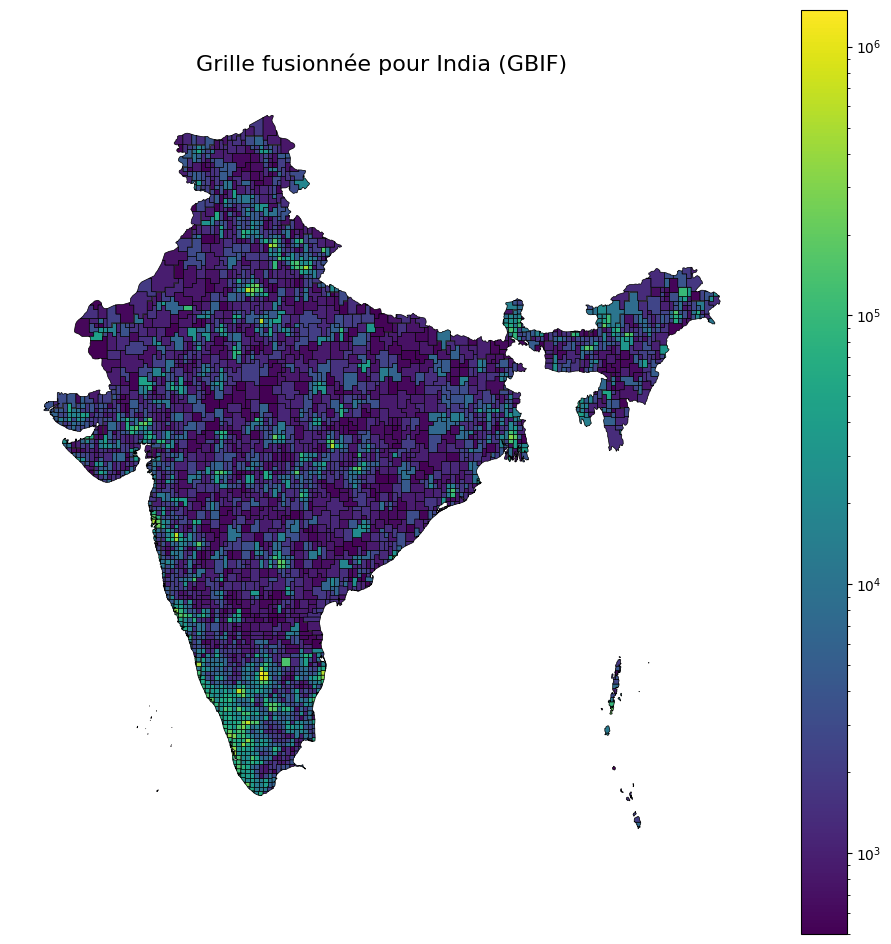

🎉 Données nettoyées sauvegardées :
   • CSV     → D:\MANTIS\Data\Biodiv\GBIF\processed\India\GBIF_India_cellID_20km_fused_minObs500_minSp50.csv
   • Parquet → D:\MANTIS\Data\Biodiv\GBIF\processed\India\GBIF_India_cellID_20km_fused_minObs500_minSp50.parquet


(WindowsPath('D:/MANTIS/Data/Biodiv/GBIF/processed/India/GBIF_India_cellID_20km_fused_minObs500_minSp50.csv'),
 WindowsPath('D:/MANTIS/Data/Biodiv/GBIF/processed/India/GBIF_India_cellID_20km_fused_minObs500_minSp50.parquet'))

In [19]:
import formatage_fusion
importlib.reload(formatage_fusion)
from formatage_fusion import fusion_cells_by_obs,apply_fusion_to_biodiv,plot_fusionned_grid,save_fusionned_biodiv,save_merged_grid,fusion_cells_by_obs_and_species

# Fusion des cellules avec seuil 1000 observations
#merged_fusion = fusion_cells_by_obs(df_final, grid, cle_geo, var_obs='nombreObs', seuil=seuil_obs)
merged_fusion=fusion_cells_by_obs_and_species(df_final, grid, cle_geo, var_obs='nombreObs', seuil=seuil_obs,cle_ID=cle_ID, min_species=seuil_species, methode="barycentre")

save_merged_grid(merged_fusion, path_data, zone, cle_geo, source, seuil_obs,seuil_species)

# gdf_fusion est votre GeoDataFrame résultant de fusion_cells_by_obs
plot_fusionned_grid(merged_fusion, var_obs='nombreObs', title=f"Grille fusionnée pour {zone} ({source})", figsize=(12,12),log_scale=True)

# Appliquer les fusions sur le dataframe original et sauvegarder
df_biodiv_fusion = apply_fusion_to_biodiv(df_final, merged_fusion, cle_geo=cle_geo, cle_ID='speciesID', var_obs='nombreObs')

save_fusionned_biodiv(df_biodiv_fusion, source, zone, cle_geo, path_data,seuil_obs,seuil_species)


In [23]:
colonnes_a_ajouter = [c for c in dico_taxo.columns if c != cle_ID]

for col in colonnes_a_ajouter:
    df_biodiv_fusion[col] = df_biodiv_fusion[cle_ID].map(dico_taxo.set_index(cle_ID)[col])

print("✅ Colonnes taxonomiques ajoutées à df_raw_import")
save_fusionned_biodiv(df_biodiv_fusion, source, zone, cle_geo, path_data,seuil_obs,seuil_species)

✅ Colonnes taxonomiques ajoutées à df_raw_import
🎉 Données nettoyées sauvegardées :
   • CSV     → D:\MANTIS\Data\Biodiv\GBIF\processed\India\GBIF_India_cellID_20km_fused_minObs500_minSp50.csv
   • Parquet → D:\MANTIS\Data\Biodiv\GBIF\processed\India\GBIF_India_cellID_20km_fused_minObs500_minSp50.parquet


(WindowsPath('D:/MANTIS/Data/Biodiv/GBIF/processed/India/GBIF_India_cellID_20km_fused_minObs500_minSp50.csv'),
 WindowsPath('D:/MANTIS/Data/Biodiv/GBIF/processed/India/GBIF_India_cellID_20km_fused_minObs500_minSp50.parquet'))